# Metacritic Metadata Cleaning
Cleans the raw movie metadata export: 
- fixes dtypes
- fixes mis-encoded text 
- normalizes title/rating/studio text, adds a primary key, and splits multi-valued columns (`cast`, `genre`, `awards`) into separate junction tables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

## 1. Load data

In [2]:
# Load the raw Excel export
meta = pd.read_excel(r"/Users/huyennguyen/Documents/MDD/SQL/Data Files/metaClean43Brightspace.xlsx")
meta.head()

,url,title,studio,rating,runtime,cast,director,genre,summary,awards,metascore,userscore,RelDate
0,https://www.metacritic.com/movie/!women-art-re...,!Women Art Revolution,Hotwire Productions,| Not Rated,83.0,NaN,Lynn Hershman-Leeson,Documentary,NaN,NaN,70,NaN,2011-06-01
1,https://www.metacritic.com/movie/10-cloverfiel...,10 Cloverfield Lane,Paramount Pictures,| PG-13,104.0,"John Gallagher Jr.,John Goodman,Mary Elizabeth...",Dan Trachtenberg,"Action,Sci-Fi,Drama,Mystery,Thriller,Horror","Waking up from a car accident, a young woman (...","#18MostDiscussedMovieof2016 , #1MostSharedMovi...",76,7.7,2016-03-11
2,https://www.metacritic.com/movie/10-items-or-less,10 Items or Less,Click Star,| R,82.0,"Jonah Hill,Morgan Freeman,Paz Vega",Brad Silberling,"Drama,Comedy,Romance",While researching a role as a supermarket mana...,NaN,54,5.8,2006-12-01
3,https://www.metacritic.com/movie/10-years,10 Years,Anchor Bay Entertainment,| R,100.0,"Channing Tatum,Chris Pratt,Jenna Dewan",Jamie Linden,"Drama,Comedy,Romance",NaN,NaN,61,6.9,2012-09-14
4,https://www.metacritic.com/movie/100-bloody-acres,100 Bloody Acres,Music Box Films,| Not Rated,91.0,NaN,Cameron Cairnes,"Horror,Comedy",Reg and Lindsay run an organic fertilizer busi...,NaN,63,7.5,2013-06-28


In [3]:
# Quick profile of the raw data
print(meta.info())
print(meta.describe())
print("Shape:", meta.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11364 entries, 0 to 11363
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   url        11364 non-null  object        
 1   title      11364 non-null  object        
 2   studio     11014 non-null  object        
 3   rating     10297 non-null  object        
 4   runtime    11109 non-null  float64       
 5   cast       7662 non-null   object        
 6   director   11350 non-null  object        
 7   genre      11344 non-null  object        
 8   summary    5467 non-null   object        
 9   awards     4387 non-null   object        
 10  metascore  11364 non-null  int64         
 11  userscore  9259 non-null   float64       
 12  RelDate    11364 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 1.1+ MB
None
            runtime     metascore    userscore                        RelDate
count  11109.000000  1

array([[<Axes: title={'center': 'runtime'}>,
        <Axes: title={'center': 'metascore'}>],
       [<Axes: title={'center': 'userscore'}>,
        <Axes: title={'center': 'RelDate'}>]], dtype=object)

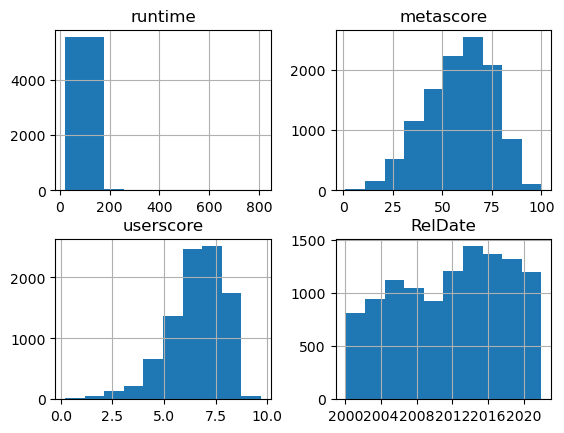

In [4]:
meta.hist()

In [5]:
# Check for fully duplicated rows
print("Duplicate rows:", meta.duplicated().sum())

Duplicate rows: 0


In [6]:
# Missing values per column: count + percentage
for col in meta.columns:
    missing_pct = meta[col].isnull().mean() * 100
    print(f"{col}: {meta[col].isnull().sum()} missing ({missing_pct:.2f}%)")

url: 0 missing (0.00%)
title: 0 missing (0.00%)
studio: 350 missing (3.08%)
rating: 1067 missing (9.39%)
runtime: 255 missing (2.24%)
cast: 3702 missing (32.58%)
director: 14 missing (0.12%)
genre: 20 missing (0.18%)
summary: 5897 missing (51.89%)
awards: 6977 missing (61.40%)
metascore: 0 missing (0.00%)
userscore: 2105 missing (18.52%)
RelDate: 0 missing (0.00%)


# Data Profiling
### The meta dataset has 11364 rows and 13 columns:
- title, studio, rating, director are currently object Dtype, and will be casted to pandas string dtype later for encoding text purpose.

### There are no dubplicated rows

### Statisic descriptions:
- runtime: mean 102.7 min, median 100 min, std ~20. It is tight and normal, but max 808 min is a clear outlier, min is a sane 21 min.

- metascore: 1–100 range fully used, mean 58.4, median 60. no missing values, complete coverage.

- userscore (0–10 scale): mean 6.5, median 6.7, std 1.37. fairly consistent, but missing for 18.5% of titles.

- RelDate: spans 2000-01-01 to 2021-12-29, median release ~2012-07-20. a 20+ year, roughly center-weighted catalog.

Conclution: the dataset is structurally clean, no missing key identifiers, but summary and awards are unreliable for completeness-dependent analysis (>50% missing), and the runtime max of 808 needs the outlier flag.


## Data type conversion
Convert free-text object columns to pandas' `string` dtype for consistent `.str` handling.

In [7]:
for col in ["url", "title", "studio", "rating", "director", "cast", "genre", "awards"]:
    meta[col] = meta[col].astype("string")

meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11364 entries, 0 to 11363
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   url        11364 non-null  string        
 1   title      11364 non-null  string        
 2   studio     11014 non-null  string        
 3   rating     10297 non-null  string        
 4   runtime    11109 non-null  float64       
 5   cast       7662 non-null   string        
 6   director   11350 non-null  string        
 7   genre      11344 non-null  string        
 8   summary    5467 non-null   object        
 9   awards     4387 non-null   string        
 10  metascore  11364 non-null  int64         
 11  userscore  9259 non-null   float64       
 12  RelDate    11364 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(1), string(8)
memory usage: 1.1+ MB


##  Fix mis-encoded text (mojibake)

title column: Fixing mis-encoded text by using title from the URL.

studio, cast, director, summary: 
Several text columns were double-encoded (UTF-8 bytes misread as Latin-1), e.g. `GÃ©rard` instead of `Gérard`. Only columns that actually contain the artifact (checked against the raw data) are fixed.

In [8]:
# Extract the title slug from the URL and turn dashes into spaces
meta["title_from_url"] = (
    meta["url"]
    .str.extract(r"/movie/([^/?#]+)", expand=False)
    .str.replace("-", " ", regex=False)
)

# Some slugs end with a "(YYYY)" year tag -> strip it off
meta["title_clean"] = (
    meta["title_from_url"]
    .str.replace(r"\s*\(\d{4}\)$", "", regex=True)
    .str.strip()
)

# Drop the old title and temporary title_from_url column
meta = meta.drop(columns=["title_from_url", "title"])
# rename title_clean and use it as final "title" name column
meta = meta.rename(columns={"title_clean": "title"})


print("Missing titles remaining:", meta["title"].isnull().sum())

print("Remaining mojibake in title:", meta["title"].str.contains("©", na=False).sum())

Missing titles remaining: 0
Remaining mojibake in title: 0


In [9]:
def try_encoding(text):
    # Reverse a UTF-8 -> Latin-1 mis-decode; leave normal text untouched.
    if pd.isna(text):
        return text
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text

for col in ["title", "studio", "cast", "director", "summary"]:
    meta[col] = meta[col].apply(try_encoding)

# Spot-check: rows that still contain the mojibake marker should now be fixed
print("Remaining mojibake in cast:", meta["cast"].str.contains("©", na=False).sum())

Remaining mojibake in cast: 0


In [10]:
# Review the data for title column again 
meta.head()

,url,studio,rating,runtime,cast,director,genre,summary,awards,metascore,userscore,RelDate,title
0,https://www.metacritic.com/movie/!women-art-re...,Hotwire Productions,| Not Rated,83.0,<NA>,Lynn Hershman-Leeson,Documentary,NaN,<NA>,70,NaN,2011-06-01,!women art revolution
1,https://www.metacritic.com/movie/10-cloverfiel...,Paramount Pictures,| PG-13,104.0,"John Gallagher Jr.,John Goodman,Mary Elizabeth...",Dan Trachtenberg,"Action,Sci-Fi,Drama,Mystery,Thriller,Horror","Waking up from a car accident, a young woman (...","#18MostDiscussedMovieof2016 , #1MostSharedMovi...",76,7.7,2016-03-11,10 cloverfield lane
2,https://www.metacritic.com/movie/10-items-or-less,Click Star,| R,82.0,"Jonah Hill,Morgan Freeman,Paz Vega",Brad Silberling,"Drama,Comedy,Romance",While researching a role as a supermarket mana...,<NA>,54,5.8,2006-12-01,10 items or less
3,https://www.metacritic.com/movie/10-years,Anchor Bay Entertainment,| R,100.0,"Channing Tatum,Chris Pratt,Jenna Dewan",Jamie Linden,"Drama,Comedy,Romance",NaN,<NA>,61,6.9,2012-09-14,10 years
4,https://www.metacritic.com/movie/100-bloody-acres,Music Box Films,| Not Rated,91.0,<NA>,Cameron Cairnes,"Horror,Comedy",Reg and Lindsay run an organic fertilizer busi...,<NA>,63,7.5,2013-06-28,100 bloody acres


##  Clean text formatting

In [11]:
# Strip leading/trailing whitespace from every free-text column
text_cols = ["title", "studio", "rating", "cast", "director", "genre", "summary", "awards"]
for col in text_cols:
    meta[col] = meta[col].str.strip()

In [12]:
# Normalize titles: lowercase, spell out "&" as "and", drop remaining punctuation
meta["title"] = meta["title"].str.lower()
meta["title"] = meta["title"].str.replace("&", "and", regex=False)
meta["title"] = meta["title"].str.replace(r"[^\w\s]", "", regex=True)
meta["title"] = meta["title"].str.strip()
meta["title"].head()

0    women art revolution
1     10 cloverfield lane
2        10 items or less
3                10 years
4        100 bloody acres
Name: title, dtype: object

In [13]:
meta["title"].value_counts()

title
mother                               2
some velvet morning                  1
soaked in bleach                     1
sobibor 14 octobre 1943 16 heures    1
sobrevivire                          1
                                    ..
held                                 1
held up                              1
heleno                               1
heli                                 1
zus zo                               1
Name: count, Length: 11363, dtype: int64

In [14]:
# rating values look like "| PG-13" (and a few typos like "PG--13", "PG-13`").
# Strip all punctuation so only the alphanumeric rating code remains, then re-strip whitespace
# left behind by removing the leading "| ".
meta["rating"] = meta["rating"].str.replace(r"[^\w\s]", "", regex=True).str.strip()

print(meta["rating"].value_counts(dropna=False))

rating
R            3515
Not Rated    2960
PG13         2031
<NA>         1067
PG            816
Unrated       384
TVMA          200
NR            128
G             124
TV14           56
NC17           40
TVPG           23
TVG             7
Open            5
Approved        4
M               2
MA17            1
MPG             1
Name: count, dtype: Int64


In [15]:
# Replace value NR to Not Rated
meta["rating"] = meta["rating"].str.replace("NR", "Not Rated", regex=True).str.strip()
print(meta["rating"].value_counts(dropna=False))

rating
R            3515
Not Rated    3088
PG13         2031
<NA>         1067
PG            816
Unrated       384
TVMA          200
G             124
TV14           56
NC17           40
TVPG           23
TVG             7
Open            5
Approved        4
M               2
MA17            1
MPG             1
Name: count, dtype: Int64


In [16]:
for col in ["title", "studio", "director"]:
    mask = meta[col].str.contains(",", na=False, regex=True)

    print(f"\n - {col} -")
    print(meta.loc[mask, [col]])



 - title -
Empty DataFrame
Columns: [title]
Index: []

 - studio -
                          studio
17        Weinstein Company, The
46       Film Collaborative, The
94        Weinstein Company, The
142       Weinstein Company, The
195    Criterion Collection, The
...                          ...
11035     Weinstein Company, The
11174     Weinstein Company, The
11318     Weinstein Company, The
11321     Weinstein Company, The
11331             Film Desk, The

[192 rows x 1 columns]

 - director -
                  director
9234   Michael Landon, Jr.
10036  Michael Landon, Jr.


In [17]:
# studio names like "Weinstein Company, The" should read as "The Weinstein Company"
meta["studio"] = meta["studio"].str.replace(
    r"^(.*),\s*(The|A|An)$", r"\2 \1", regex=True)

meta["studio"] = meta["studio"].str.replace(
    '"', "", regex=True)

In [18]:
# Check studio unique values
print(meta["studio"].value_counts(dropna=False))

# Check again if the studio values still have ","
print("studio names contain ',' : ", meta["studio"].str.contains(",", na=False, regex=True).sum())


studio
IFC Films                                  408
<NA>                                       350
Universal Pictures                         345
Sony Pictures Classics                     344
Warner Bros. Pictures                      302
                                          ... 
Empire Film Group                            1
Mill Creek Entertainment                     1
American International Pictures              1
Dartmouth Films                              1
20th Century Fox International Classics      1
Name: count, Length: 1114, dtype: int64
studio names contain ',' :  0


## Add a primary key for id_movie
`title` alone has 219 duplicate values across different movies, so it can't safely be used as a join key for the junction tables below — a stable `id_movie` is needed instead.

In [19]:
# Create id primary key for movie title

meta = meta.reset_index(drop=True)
meta.insert(0, "id_movie", range(1, len(meta) + 1))

In [20]:
meta[['id_movie', 'title']].head()

,id_movie,title
0,1,women art revolution
1,2,10 cloverfield lane
2,3,10 items or less
3,4,10 years
4,5,100 bloody acres


In [21]:
meta[['id_movie', 'title']].value_counts()

id_movie  title                            
1         women art revolution                 1
7548      smashed                              1
7572      so much so fast                      1
7573      soaked in bleach                     1
7574      sobibor 14 octobre 1943 16 heures    1
                                              ..
3790      held                                 1
3791      held up                              1
3792      heleno                               1
3793      heli                                 1
11364     zus zo                               1
Name: count, Length: 11364, dtype: int64

In [22]:
meta[['id_movie', 'title']].duplicated().value_counts()

False    11364
Name: count, dtype: int64

##  Flag runtime outliers
Runtime tops out at 808 minutes — implausible for a single feature, so flag rows above 300 minutes for manual review rather than guessing a correction.

In [23]:
meta["runtime_outlier"] = meta["runtime"] > 300
print("Runtime outliers flagged:", meta["runtime_outlier"].sum())

Runtime outliers flagged: 3


##  Split multi-valued columns into junction tables
`cast`, `genre`, and `awards` hold comma-separated lists in a single cell. Split each into a Python list, then explode into its own long-format table keyed by `id_movie` — **not** chained together, since exploding three list columns on the same row would cross-multiply them into a combinatorial explosion (e.g. 3 cast x 6 genre x N awards).

In [24]:
# Split into lists; awards has inconsistent spacing around commas so uses a regex split
meta["cast_list"] = meta["cast"].str.split(",")
meta["genre_list"] = meta["genre"].str.split(",")
meta["awards_list"] = meta["awards"].str.split(r"\s*,\s*", regex=True)

# Strip whitespace from each item in the lists
for col in ["cast_list", "genre_list", "awards_list"]:
    meta[col] = meta[col].apply(lambda lst: [x.strip() for x in lst] if isinstance(lst, list) else lst)

# .apply() processes each with unnormalised row separately 
# lambda lst is used to create unknown function like def clean_list(lst):, variable lst shows a list of values in one row/cell
# then check if values in lst is a list by using "if isinstance(lst, list)
# then remove whitespace around x which is assigned as words inside the list, for example: " Tom Hanks " -> "Tom Hanks"

In [25]:
meta["genre_list"].head(10)

0                                        [Documentary]
1    [Action, Sci-Fi, Drama, Mystery, Thriller, Hor...
2                             [Drama, Comedy, Romance]
3                             [Drama, Comedy, Romance]
4                                     [Horror, Comedy]
5                                              [Drama]
6                                              [Drama]
7                          [Adventure, Drama, Fantasy]
8                             [Drama, Comedy, Romance]
9                                              [Drama]
Name: genre_list, dtype: object

## Create Movie Genre table from meta dataset

In [26]:
# Junction table: one row per (movie, genre)
movie_genre = (
    meta[["id_movie", "title", "genre_list"]]
    .explode("genre_list")                  # separate values from the list into different rows, creates one row for each item in that list
    .rename(columns={"genre_list": "genre"})
    .dropna(subset=["genre"])               #This removes rows where genre is NaN, subset=["genre"]: check the genre column for missing values
    .reset_index(drop=True)                 #creates a new clean index without repeating index like 0 0, 1 1 1, 2 2, but 0, 1, 2,...
)
movie_genre.head(10)

,id_movie,title,genre
0,1,women art revolution,Documentary
1,2,10 cloverfield lane,Action
2,2,10 cloverfield lane,Sci-Fi
3,2,10 cloverfield lane,Drama
4,2,10 cloverfield lane,Mystery
5,2,10 cloverfield lane,Thriller
6,2,10 cloverfield lane,Horror
7,3,10 items or less,Drama
8,3,10 items or less,Comedy
9,3,10 items or less,Romance


In [27]:
movie_genre.shape

(27055, 3)

# Create cast table

In [28]:
# Junction table: one row per (movie, cast member)
movie_cast = (
    meta[["id_movie", "title", "cast_list"]]
    .explode("cast_list")
    .rename(columns={"cast_list": "cast"})
    .dropna(subset=["cast"])
    .reset_index(drop=True)
)
movie_cast.head(10)

,id_movie,title,cast
0,2,10 cloverfield lane,John Gallagher Jr.
1,2,10 cloverfield lane,John Goodman
2,2,10 cloverfield lane,Mary Elizabeth Winstead
3,3,10 items or less,Jonah Hill
4,3,10 items or less,Morgan Freeman
5,3,10 items or less,Paz Vega
6,4,10 years,Channing Tatum
7,4,10 years,Chris Pratt
8,4,10 years,Jenna Dewan
9,8,10000 bc,Camilla Belle


In [29]:
# Create cast tbl from movie_cast table, drop duplicates
cast_tbl = (
    movie_cast[["cast"]]
    .drop_duplicates()
    .sort_values("cast")
    .reset_index(drop=True)
)

print(cast_tbl.head())
print(cast_tbl.shape)
print(cast_tbl.duplicated().sum())

               cast
0                  
1           50 Cent
2           6ix9ine
3        A Martinez
4  A. Brian Daniels
(24862, 1)
0


In [30]:
# Create genre id

cast_tbl.insert(0, "id_character", range(1, len(cast_tbl) + 1))

cast_tbl = cast_tbl.rename(columns={"cast": "character_name"})

print(cast_tbl.head())
print(cast_tbl.shape)

   id_character    character_name
0             1                  
1             2           50 Cent
2             3           6ix9ine
3             4        A Martinez
4             5  A. Brian Daniels
(24862, 2)


# Create awards table

In [31]:
# Junction table: one row per (movie, award)
movie_awards = (
    meta[["id_movie", "title", "awards_list"]]
    .explode("awards_list")
    .rename(columns={"awards_list": "awards"})
    .dropna(subset=["awards"])
    .reset_index(drop=True)
)
movie_awards.head(10)

,id_movie,title,awards
0,2,10 cloverfield lane,#18MostDiscussedMovieof2016
1,2,10 cloverfield lane,#1MostSharedMovieof2016
2,8,10000 bc,#23MostDiscussedMovieof2008
3,8,10000 bc,#27MostSharedMovieof2008
4,12,102 dalmatians,#73MostDiscussedMovieof2000
5,17,12,#97BestMovieof2009
6,17,12,#18MostSharedMovieof2009
7,22,12 rounds,#71MostSharedMovieof2009
8,23,12 strong,#77MostDiscussedMovieof2018
9,23,12 strong,#21MostSharedMovieof2018


In [32]:
# Create awards tbl from movie_awards table, drop duplicates
awards_tbl = (
    movie_awards[["awards"]]
    .drop_duplicates()
    .sort_values("awards")
    .reset_index(drop=True)
)

print(awards_tbl.head())
print(awards_tbl.shape)
print(awards_tbl.duplicated().sum())

                awards
0  #100BestMovieof2000
1  #100BestMovieof2001
2  #100BestMovieof2002
3  #100BestMovieof2003
4  #100BestMovieof2004
(6407, 1)
0


In [33]:
# Create awards id

awards_tbl.insert(0, "id_award", range(1, len(awards_tbl) + 1))

awards_tbl = awards_tbl.rename(columns={"awards": "award_name"})


print(awards_tbl.head())
print(awards_tbl.shape)

   id_award           award_name
0         1  #100BestMovieof2000
1         2  #100BestMovieof2001
2         3  #100BestMovieof2002
3         4  #100BestMovieof2003
4         5  #100BestMovieof2004
(6407, 2)


##  Build the meta_cleaned movie table
One row per movie — the multi-valued columns now live in the junction tables above, so they're dropped here to avoid duplicating movie-level data.

In [34]:
meta_cleaned = meta.drop(columns=["cast", "genre", "awards", "cast_list", "genre_list", "awards_list"])
meta_cleaned.head()

,id_movie,url,studio,rating,runtime,director,summary,metascore,userscore,RelDate,title,runtime_outlier
0,1,https://www.metacritic.com/movie/!women-art-re...,Hotwire Productions,Not Rated,83.0,Lynn Hershman-Leeson,NaN,70,NaN,2011-06-01,women art revolution,False
1,2,https://www.metacritic.com/movie/10-cloverfiel...,Paramount Pictures,PG13,104.0,Dan Trachtenberg,"Waking up from a car accident, a young woman (...",76,7.7,2016-03-11,10 cloverfield lane,False
2,3,https://www.metacritic.com/movie/10-items-or-less,Click Star,R,82.0,Brad Silberling,While researching a role as a supermarket mana...,54,5.8,2006-12-01,10 items or less,False
3,4,https://www.metacritic.com/movie/10-years,Anchor Bay Entertainment,R,100.0,Jamie Linden,NaN,61,6.9,2012-09-14,10 years,False
4,5,https://www.metacritic.com/movie/100-bloody-acres,Music Box Films,Not Rated,91.0,Cameron Cairnes,Reg and Lindsay run an organic fertilizer busi...,63,7.5,2013-06-28,100 bloody acres,False


# Create rating table

In [35]:
# Create rating tbl from meta_cleaned table, drop duplicates
rating_tbl = (
    meta_cleaned[["rating"]]
    .drop_duplicates()
    .sort_values("rating")
    .reset_index(drop=True)
)

# Create rating id
#
rating_tbl.insert(0, "id_rating", range(1, len(rating_tbl) + 1))
rating_tbl = rating_tbl.rename(columns={"rating": "rating_code"})

print(rating_tbl.head())
print(rating_tbl.shape)
print(rating_tbl.duplicated().sum())
rating_tbl.value_counts()

   id_rating rating_code
0          1    Approved
1          2           G
2          3           M
3          4        MA17
4          5         MPG
(17, 2)
0


id_rating  rating_code
1          Approved       1
2          G              1
3          M              1
4          MA17           1
5          MPG            1
6          NC17           1
7          Not Rated      1
8          Open           1
9          PG             1
10         PG13           1
11         R              1
12         TV14           1
13         TVG            1
14         TVMA           1
15         TVPG           1
16         Unrated        1
Name: count, dtype: int64

In [36]:

# create dictionary mapping the rating codes to full rating names
rating_mapping = {
    'Approved': 'Approved',
    'G': 'General Audiences',
    'M': 'Mature Audiences',
    'MA17': 'Mature Audiences over 17',
    'MPG': 'Mature Parental Guidance',
    'NC17': 'No One 17 and Under Admitted',
    'NR': 'Not Rated',
    'Not Rated': 'Not Rated',
    'Open': 'Open',
    'PG': 'Parental Guidance Suggested',
    'PG13': 'Parents Strongly Cautioned',
    'R': 'Restricted',
    'TVG': 'TV rating General Audience',
    'TVPG': 'TV Parental Guidance Suggested',
    'TV14': 'TV Parents Strongly Cautioned',
    'TVMA': 'TV Mature Audience Only',
    'Unrated': 'Unrated'
}

# 3. Insert the new column next to 'rating_code' (Index position 2)
rating_tbl.insert(loc=1, column='rating_name', value=rating_tbl['rating_code'].map(rating_mapping))

# View the result
print(rating_tbl)



    id_rating                     rating_name rating_code
0           1                        Approved    Approved
1           2               General Audiences           G
2           3                Mature Audiences           M
3           4        Mature Audiences over 17        MA17
4           5        Mature Parental Guidance         MPG
5           6    No One 17 and Under Admitted        NC17
6           7                       Not Rated   Not Rated
7           8                            Open        Open
8           9     Parental Guidance Suggested          PG
9          10      Parents Strongly Cautioned        PG13
10         11                      Restricted           R
11         12   TV Parents Strongly Cautioned        TV14
12         13      TV rating General Audience         TVG
13         14         TV Mature Audience Only        TVMA
14         15  TV Parental Guidance Suggested        TVPG
15         16                         Unrated     Unrated
16         17 

In [37]:
meta_cleaned.columns

Index(['id_movie', 'url', 'studio', 'rating', 'runtime', 'director', 'summary',
       'metascore', 'userscore', 'RelDate', 'title', 'runtime_outlier'],
      dtype='object')

In [38]:
# Create id_rating as foreign key for meta_cleaned table

meta_cleaned = (
    meta_cleaned[['id_movie', 'url', 'studio', 'rating', 'runtime', 'director', 'summary',
       'metascore', 'userscore', 'RelDate', 'title', 'runtime_outlier']]
    .merge(
        rating_tbl,
        left_on="rating",       # "rating" column from meta_cleaned
        right_on="rating_code", # matching column in rating_tbl
        how="left"
    )
    .drop(columns=["rating", "rating_code"])
)

# Final column selection
meta_cleaned = (
    meta_cleaned[["id_movie", "id_rating", 'title', 'studio', 'runtime', 'director', 'summary',
       'metascore', 'userscore', 'RelDate',  'runtime_outlier', 'url']]
    .reset_index(drop=True)
)

print(meta_cleaned.shape)
meta_cleaned.head()

(11364, 12)


,id_movie,id_rating,title,studio,runtime,director,summary,metascore,userscore,RelDate,runtime_outlier,url
0,1,7,women art revolution,Hotwire Productions,83.0,Lynn Hershman-Leeson,NaN,70,NaN,2011-06-01,False,https://www.metacritic.com/movie/!women-art-re...
1,2,10,10 cloverfield lane,Paramount Pictures,104.0,Dan Trachtenberg,"Waking up from a car accident, a young woman (...",76,7.7,2016-03-11,False,https://www.metacritic.com/movie/10-cloverfiel...
2,3,11,10 items or less,Click Star,82.0,Brad Silberling,While researching a role as a supermarket mana...,54,5.8,2006-12-01,False,https://www.metacritic.com/movie/10-items-or-less
3,4,11,10 years,Anchor Bay Entertainment,100.0,Jamie Linden,NaN,61,6.9,2012-09-14,False,https://www.metacritic.com/movie/10-years
4,5,7,100 bloody acres,Music Box Films,91.0,Cameron Cairnes,Reg and Lindsay run an organic fertilizer busi...,63,7.5,2013-06-28,False,https://www.metacritic.com/movie/100-bloody-acres


# Create Movie table from meta dataset

In [39]:
#Create movie_tbl with id_movie and title, drop duplicated based on movie id
movie_tbl_m = (
    meta_cleaned[["id_movie", "id_rating", "title", "runtime", "metascore", "userscore", "RelDate", "url"]]
    .drop_duplicates(subset="id_movie") # removes duplicate rows based only on the id_movie column
    .reset_index(drop=True) 
    )

print(movie_tbl_m.shape)
print(movie_tbl_m.duplicated().sum())

movie_tbl_m.head()

(11364, 8)
0


,id_movie,id_rating,title,runtime,metascore,userscore,RelDate,url
0,1,7,women art revolution,83.0,70,NaN,2011-06-01,https://www.metacritic.com/movie/!women-art-re...
1,2,10,10 cloverfield lane,104.0,76,7.7,2016-03-11,https://www.metacritic.com/movie/10-cloverfiel...
2,3,11,10 items or less,82.0,54,5.8,2006-12-01,https://www.metacritic.com/movie/10-items-or-less
3,4,11,10 years,100.0,61,6.9,2012-09-14,https://www.metacritic.com/movie/10-years
4,5,7,100 bloody acres,91.0,63,7.5,2013-06-28,https://www.metacritic.com/movie/100-bloody-acres


# Create studio table

In [40]:
# Create studio tbl from meta_cleaned table, drop duplicates
studio_tbl = (
    meta_cleaned[["studio"]]
    .drop_duplicates()
    .sort_values("studio")
    .reset_index(drop=True)
)

print(studio_tbl.head())
print(studio_tbl.shape)
print(studio_tbl.duplicated().sum())

                       studio
0             01 Distribution
1                   108 Media
2                  1091 Media
3            20th Century Fox
4  20th Century Fox Argentina
(1114, 1)
0


In [41]:
# Create studio id

studio_tbl.insert(0, "id_studio", range(1, len(studio_tbl) + 1))
studio_tbl = studio_tbl.rename(columns={"studio": "studio_name"})
print(studio_tbl.head())
print(studio_tbl.shape)

   id_studio                 studio_name
0          1             01 Distribution
1          2                   108 Media
2          3                  1091 Media
3          4            20th Century Fox
4          5  20th Century Fox Argentina
(1114, 2)


# Create director table

In [42]:
# Create studio tbl from meta_cleaned table, drop duplicates
director_tbl = (
    meta_cleaned[["director"]]
    .drop_duplicates()
    .sort_values("director")
    .reset_index(drop=True)
)

# Create director id
director_tbl.insert(0, "id_director", range(1, len(director_tbl) + 1))
director_tbl = director_tbl.rename(columns={"director": "director_name"})

print(director_tbl.head())
print(director_tbl.shape)
print(director_tbl.duplicated().sum())

   id_director director_name
0            1  A. Dean Bell
1            2   A.B. Shawky
2            3    A.J. Eaton
3            4  A.J. Edwards
4            5    AJ Schnack
(6137, 2)
0


###  Create bridge_movie_cast

In [43]:
# Movie–Cast bridge table
bridge_movie_cast = (
    movie_cast[["id_movie", "cast"]]
    .merge(
        cast_tbl,
        left_on="cast",
        right_on="character_name",
        how="left"
    )
    [["id_movie", "id_character"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_cast.head(10)

,id_movie,id_character
0,2,11725
1,2,11733
2,2,16027
3,3,11940
4,3,17415
5,3,18975
6,4,4074
7,4,4418
8,4,10965
9,8,3656


### 3. bridge_movie_awards

In [44]:
# Movie–Awards bridge table
bridge_movie_awards = (
    movie_awards[["id_movie", "awards"]]
    .merge(
        awards_tbl,
        left_on="awards",
        right_on="award_name",
        how="left"
    )
    [["id_movie", "id_award"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_awards.head(10)

,id_movie,id_award
0,2,621
1,2,771
2,8,998
3,8,1274
4,12,4512
5,17,6160
6,17,636
7,22,4415
8,23,4786
9,23,903


### 4. bridge_movie_director

In [45]:
# Movie–Awards bridge table
bridge_movie_director = (
    meta_cleaned[["id_movie", "director"]]      # from meta_cleaned tbl, select onl two columns need
    .merge(                                     # merge with director tbl
        director_tbl,
        left_on="director",                     # use director from the left dataframe: meta_cleaned
        right_on="director_name",               # match director from meta_cleaned against the director_name from the right dataframe: director_tbl
        how="left"                              # keep every row from meta_cleaned, even having no director found in director_tbl
    )
    [["id_movie", "id_director"]]               # Keep only id_movie and id_director
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_director.head(10)

,id_movie,id_director
0,1,3798
1,2,1380
2,3,804
3,4,2640
4,5,927
5,6,2922
6,7,1954
7,8,5138
8,9,959
9,10,697


### 5. bridge_movie_studio


In [46]:
# Movie–Studio bridge table
bridge_movie_studio = (
    meta_cleaned[["id_movie", "studio"]]      # from meta_cleaned tbl, select onl two columns need
    .merge(                                     # merge with studio tbl
        studio_tbl,
        left_on="studio",                     # use studio from the left dataframe: meta_cleaned
        right_on="studio_name",               # match studio from meta_cleaned against the studio_name from the right dataframe: studio_tbl
        how="left"                              # keep every row from meta_cleaned, even having no studio found in studio_tbl
    )
    [["id_movie", "id_studio"]]               # Keep only id_movie and id_studio
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_studio.head(10)

,id_movie,id_studio
0,1,488
1,2,768
2,3,247
3,4,74
4,5,679
5,6,863
6,7,378
7,8,1070
8,9,177
9,10,552


## Final quality check and export

In [47]:
print("FINAL DATA QUALITY CHECK")
print("Movies:", meta_cleaned.shape)
print("Unique id_movie:", meta_cleaned["id_movie"].is_unique)
print("Runtime outliers flagged:", meta_cleaned["runtime_outlier"].sum())
print("cast rows:", cast_tbl.shape)
print("awards rows:", awards_tbl.shape)
print("studio rows:", studio_tbl.shape)
print("director rows:", director_tbl.shape)
print("rating rows:", rating_tbl.shape)


FINAL DATA QUALITY CHECK
Movies: (11364, 12)
Unique id_movie: True
Runtime outliers flagged: 3
cast rows: (24862, 2)
awards rows: (6407, 2)
studio rows: (1114, 2)
director rows: (6137, 2)
rating rows: (17, 3)


# Sales Dataset

In [48]:
# Load the raw Excel export
sales = pd.read_excel(r"/Users/huyennguyen/Documents/MDD/SQL/Data Files/sales.xlsx")

In [49]:
# Quick profile of the raw data: shape, dtypes, and % missing per column
print("Shape:", sales.shape)
sales.info()
print("\nMissing values (%):")
print((sales.isnull().mean() * 100).round(2))

Shape: (30612, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30604 non-null  object 
 3   genre                     28908 non-null  object 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   Unnamed: 8                0 non-null      float64
 9   opening_weekend           10929 non-null  float64
 10  theatre_count             10963 non-null  float64
 11  avg run per theatre       10952 non-null  float64
 12  runtime                   24559 non-null  float64
 13  keywords                  12517 non-null  

In [50]:
sales.describe()

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,2.157500e+04,1.188400e+04,2.157500e+04,4.480000e+03,0.0,1.092900e+04,10963.000000,10952.000000,24559.000000
mean,2014.542108,1.586202e+07,1.735331e+07,2.524796e+07,3.642238e+07,NaN,5.488562e+06,723.147040,4.124562,101.502993
std,5.525085,6.659680e+07,5.050972e+07,1.009796e+08,4.644049e+07,NaN,1.633207e+07,1246.401636,3.423855,27.194334
min,2000.000000,2.000000e+00,2.000000e+01,2.000000e+00,1.100000e+03,NaN,1.100000e+01,1.000000,0.000000,11.000000
25%,2012.000000,2.637500e+04,2.986550e+04,3.422900e+04,6.500000e+06,NaN,7.352000e+03,2.000000,2.000000,89.000000
50%,2016.000000,3.348470e+05,2.587510e+05,4.753220e+05,2.000000e+07,NaN,4.087500e+04,8.000000,3.400000,97.000000
75%,2019.000000,4.282312e+06,7.667212e+06,6.302152e+06,4.500000e+07,NaN,2.150979e+06,969.500000,5.400000,110.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,NaN,3.571150e+08,4725.000000,88.400000,2020.000000


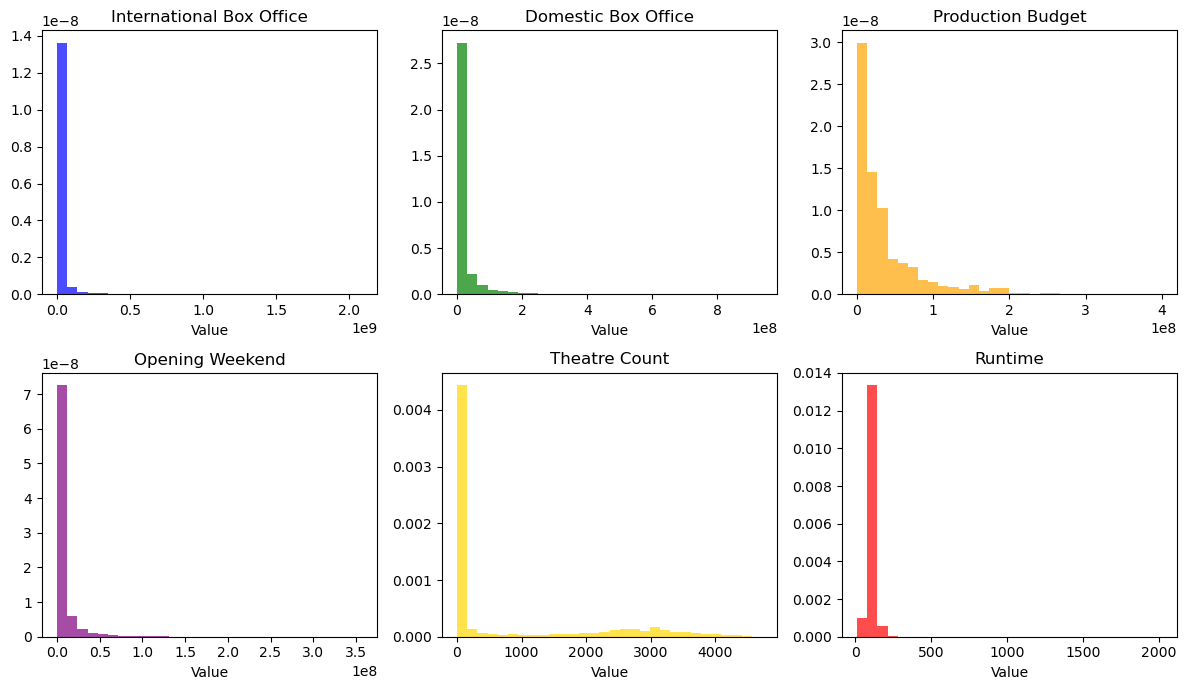

In [51]:
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
# Flatten the 2D array into 6 axes
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# Plot international box office
ax1.hist(
    sales["international_box_office"],
    bins=30,
    density=True,
    alpha=0.7,
    color="blue"
)
ax1.set_title("International Box Office")
ax1.set_xlabel("Value")

# Plot domestic box office
ax2.hist(
    sales["domestic_box_office"],
    bins=30,
    density=True,
    alpha=0.7,
    color="green"
)
ax2.set_title("Domestic Box Office")
ax2.set_xlabel("Value")

# Plot production budget
ax3.hist(
    sales["production_budget"],
    bins=30,
    density=True,
    alpha=0.7,
    color="orange"
)
ax3.set_title("Production Budget")
ax3.set_xlabel("Value")

# Plot opening weekend
ax4.hist(
    sales["opening_weekend"],
    bins=30,
    density=True,
    alpha=0.7,
    color="purple"
)
ax4.set_title("Opening Weekend")
ax4.set_xlabel("Value")

# Plot theatre count
ax5.hist(
    sales["theatre_count"],
    bins=30,
    density=True,
    alpha=0.7,
    color="gold"
)
ax5.set_title("Theatre Count")
ax5.set_xlabel("Value")

# Plot runtime
ax6.hist(
    sales["runtime"],
    bins=30,
    density=True,
    alpha=0.7,
    color="red"
)
ax6.set_title("Runtime")
ax6.set_xlabel("Value")

# Adjust layout
plt.tight_layout()

# Display the figure
plt.show()

In [52]:
# Standardize column names: trim spaces, lowercase, replace spaces with underscores
sales.columns = (
    sales.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [53]:
# Drop columns that are entirely empty (e.g. a stray "Unnamed: 8" column)
sales = sales.dropna(axis=1, how="all")

In [54]:
# Strip leading/trailing whitespace from every text (object) column
text_columns = sales.select_dtypes(include="object").columns
for column in text_columns:
    sales[column] = sales[column].str.strip()

In [55]:
# Check for fully duplicated rows
print("Duplicate rows:", sales.duplicated().sum())

Duplicate rows: 0


In [56]:
sales.head(10)

,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg_run_per_theatre,runtime,keywords,creative_type,url
0,2000,January 1st,Bakha Satang,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2001,January 12th,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,5486209.0,2433.0,3.1,NaN,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,2000,January 28th,Santitos,NaN,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos
3,2002,2002 (Wide) by,Frank McKlusky C.I.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.the-numbers.com/movie/Frank-McKlus...
4,2002,January 25th,A Walk to Remember,Drama,4833792.0,41227069.0,46060861.0,11000000.0,12177488.0,2411.0,5.3,NaN,Coming of Age,Contemporary Fiction,https://www.the-numbers.com/movie/Walk-to-Reme...
5,2002,June 21st,Zig Zag,NaN,NaN,1649.0,NaN,NaN,1649.0,1.0,1.0,NaN,NaN,NaN,https://www.the-numbers.com/movie/Zig-Zag
6,2002,May 10th,TakhtÃƒÂ© siah,Drama,NaN,21324.0,NaN,NaN,1500.0,5.0,2.0,NaN,Foreign Language,NaN,https://www.the-numbers.com/movie/Takhte-siah
7,2009,January 2nd,"Angry Monk: Reflections on Tibet, The",Documentary,NaN,2125.0,NaN,NaN,2125.0,1.0,1.0,NaN,NaN,Factual,https://www.the-numbers.com/movie/Angry-Monk-R...
8,2002,June 7th,30 Years to Life,Comedy,NaN,99023.0,NaN,NaN,3376.0,1.0,3.3,NaN,NaN,NaN,https://www.the-numbers.com/movie/30-Years-to-...
9,2008,January 2nd,The Killing of John Lennon,Drama,NaN,6975.0,NaN,NaN,3077.0,1.0,3.0,NaN,NaN,Dramatization,https://www.the-numbers.com/movie/Killing-of-J...


In [57]:
# First Convert title column from tuple to string
for col in ["url", "title","genre", "creative_type", "keywords"]:
    sales[col] = sales[col].astype("string")

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30534 non-null  string 
 3   genre                     28908 non-null  string 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   opening_weekend           10929 non-null  float64
 9   theatre_count             10963 non-null  float64
 10  avg_run_per_theatre       10952 non-null  float64
 11  runtime                   24559 non-null  float64
 12  keywords                  12509 non-null  string 
 13  creative_type             26667 non-null  string 
 14  url   

In [58]:
# Extract the title slug from the URL and turn dashes into spaces
sales["title_from_url"] = (
    sales["url"]
    .str.extract(r"/movie/([^/?#]+)", expand=False)
    .str.replace("-", " ", regex=False)
)

# Some slugs end with a "(YYYY)" year tag -> strip it off
sales["title_clean"] = (
    sales["title_from_url"]
    .str.replace(r"\s*\(\d{4}\)$", "", regex=True)
    .str.strip()
)

# Fill only the missing titles with the recovered value, then drop the helper columns
# sales.loc[sales["title"].isnull(), "title"] = sales.loc[sales["title"].isnull(), "title_clean"]

sales = sales.drop(columns=["title_from_url", "title"])
# rename title_clean and use it as final title name column
sales = sales.rename(columns={"title_clean": "title"})


print("Missing titles remaining:", sales["title"].isnull().sum())

print("Remaining mojibake in title:", sales["title"].str.contains("©", na=False).sum())

Missing titles remaining: 0
Remaining mojibake in title: 0


In [59]:
# Normalize casing/spacing so titles compare and group consistently
sales["title"] = sales["title"].str.lower().str.strip()

In [60]:
# Normalize titles: lowercase, spell out "&" as "and", drop remaining punctuation

sales["title"] = sales["title"].str.replace("&", "and", regex=False)
sales["title"] = sales["title"].str.replace(r"[^\w\s]", "", regex=True)
sales["title"] = sales["title"].str.strip()
sales["title"].head()

0    bakha satang s korea
1               antitrust
2                santitos
3      frank mcklusky c i
4      walk to remember a
Name: title, dtype: string

In [61]:
sales.head()

,year,release_date,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg_run_per_theatre,runtime,keywords,creative_type,url,title
0,2000,January 1st,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,129.0,<NA>,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...,bakha satang s korea
1,2001,January 12th,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,5486209.0,2433.0,3.1,NaN,<NA>,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust,antitrust
2,2000,January 28th,<NA>,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,105.0,<NA>,<NA>,https://www.the-numbers.com/movie/Santitos,santitos
3,2002,2002 (Wide) by,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,https://www.the-numbers.com/movie/Frank-McKlus...,frank mcklusky c i
4,2002,January 25th,Drama,4833792.0,41227069.0,46060861.0,11000000.0,12177488.0,2411.0,5.3,NaN,Coming of Age,Contemporary Fiction,https://www.the-numbers.com/movie/Walk-to-Reme...,walk to remember a


In [62]:
# Remove ordinal suffixes ("1st" -> "1", "2nd" -> "2", ...) so the date is parseable
sales["release_date_temp"] = sales["release_date"].str.replace(
    r"(\d+)(st|nd|rd|th)", r"\1", regex=True
)

# Combine with the year column and parse; unparseable rows become NaT instead of raising
sales["release_date_clean"] = pd.to_datetime(
    sales["release_date_temp"] + " " + sales["year"].astype(str),
    errors="coerce"
)
sales = sales.drop(columns=["release_date_temp"])

print("Rows where date could not be parsed:", sales["release_date_clean"].isnull().sum())

Rows where date could not be parsed: 46


In [63]:
# The 46 unparsed rows have no usable day/month (e.g. "August", "2020 (Canceled) by ...",
# "Week of April 13th") so an exact date can't be recovered — fall back to January 1st
# of the release year, and flag those rows so they're never mistaken for a precise date.
sales["release_date_estimated"] = sales["release_date_clean"].isnull()

sales["release_date_clean"] = sales["release_date_clean"].fillna(
    pd.to_datetime(sales["year"], format="%Y")
)

print("Filled from year:", sales["release_date_estimated"].sum())
print("Still missing:", sales["release_date_clean"].isnull().sum())

Filled from year: 46
Still missing: 0


In [64]:
# Reset the index and add a table, unique row identifier
sales = sales.reset_index(drop=True)
sales.insert(0, "id_sales", range(1, len(sales) + 1))

In [65]:

# Check duplicated movies based on release date/year
sales[["title", "year", "release_date_clean"]].duplicated().sum()

0

In [66]:
# Reset the index and add a table, unique row identifier
sales = sales.reset_index(drop=True)
sales.insert(0, "id_movie", range(1, len(sales) + 1))

In [67]:
#Create movie_tbl with id_movie and title, drop duplicated based on movie id
movie_tbl_s = (
    sales[["id_movie", "title", "year", "release_date_clean","creative_type", "url"]]
    .drop_duplicates(subset="id_movie") # removes duplicate rows based only on the id_movie column
    .reset_index(drop=True) 
    )

print(movie_tbl_s.shape)
print(movie_tbl_s.duplicated().sum())

movie_tbl_s.head()

(30612, 6)
0


,id_movie,title,year,release_date_clean,creative_type,url
0,1,bakha satang s korea,2000,2000-01-01,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2,antitrust,2001,2001-01-12,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,3,santitos,2000,2000-01-28,<NA>,https://www.the-numbers.com/movie/Santitos
3,4,frank mcklusky c i,2002,2002-01-01,<NA>,https://www.the-numbers.com/movie/Frank-McKlus...
4,5,walk to remember a,2002,2002-01-25,Contemporary Fiction,https://www.the-numbers.com/movie/Walk-to-Reme...


In [68]:
# Sanity-check: box office / budget / runtime figures should never be negative
numeric_columns = [
    "international_box_office", "domestic_box_office", "worldwide_box_office",
    "production_budget", "opening_weekend", "theatre_count",
    "avg_run_per_theatre", "runtime"
]
for column in numeric_columns:
    print(column, "negative values:", (sales[column] < 0).sum())

international_box_office negative values: 0
domestic_box_office negative values: 0
worldwide_box_office negative values: 0
production_budget negative values: 0
opening_weekend negative values: 0
theatre_count negative values: 0
avg_run_per_theatre negative values: 0
runtime negative values: 0


In [69]:
# Flag implausible runtimes for review
sales["runtime_outlier"] = sales["runtime"] > 400

# Start from the raw runtime, then apply verified corrections
sales["runtime_clean"] = sales["runtime"]

# Verified against the source page for each title:
sales.loc[sales["id_sales"] == 27958, "runtime_clean"] = 83  # Barbara Lee: Speaking Truth to Power
sales.loc[sales["id_sales"] == 16351, "runtime_clean"] = 88  # Amžinai kartu
sales.loc[sales["id_sales"] == 3432, "runtime_clean"] = 77   # Meesterspion

# Label each row's review status for transparency
sales["runtime_status"] = "normal"
sales.loc[sales["runtime_outlier"], "runtime_status"] = "reviewed_outlier"
sales.loc[sales["runtime_clean"] != sales["runtime"], "runtime_status"] = "corrected"

# Create genre table from sales dataset

In [70]:
# Split into lists; awards has inconsistent spacing around commas so uses a regex split
sales["genre_list"] = sales["genre"].str.split(",")
sales["genre_list"] = sales["genre"].str.split("/")

# Strip whitespace from each item in the lists
for col in ["genre_list"]:
    sales[col] = sales[col].apply(lambda lst: [x.strip() for x in lst] if isinstance(lst, list) else lst)

In [71]:
sales["genre_list"].head()

0                 [Drama]
1    [Thriller, Suspense]
2                    <NA>
3                    <NA>
4                 [Drama]
Name: genre_list, dtype: object

In [72]:
# Create Junction table: one row per id_sales, id_movie and genre

movie_genre_s = (
    sales[["id_movie", "title", "genre_list"]]
    .explode("genre_list")                  # separate values from the list into different rows, creates one row for each item in that list
    .rename(columns={"genre_list": "genre"})
    .dropna(subset=["genre"])               #This removes rows where genre is NaN, subset=["genre"]: check the genre column for missing values
    .reset_index(drop=True)                 #creates a new clean index without repeating index like 0 0, 1 1 1, 2 2, but 0, 1, 2,...
)
movie_genre_s.head(10)


,id_movie,title,genre
0,1,bakha satang s korea,Drama
1,2,antitrust,Thriller
2,2,antitrust,Suspense
3,5,walk to remember a,Drama
4,7,takhte siah,Drama
5,8,angry monk reflections on tibet the,Documentary
6,9,30 years to life,Comedy
7,10,killing of john lennon the,Drama
8,11,mad money,Comedy
9,12,little chenier,Drama


In [73]:
movie_genre_s.shape

(31900, 3)

In [74]:
# Junction table: one row per (movie, genre)
sales_cleaned = (
    sales[["id_sales", "id_movie", "release_date_clean", "title",	
            "international_box_office",	"domestic_box_office",	
            "worldwide_box_office",	"production_budget",	
            "opening_weekend",	"theatre_count",	
            "avg_run_per_theatre",	"runtime", "keywords","url"]]
    .drop_duplicates(subset=["id_sales"])
    .reset_index(drop=True)
)

print(sales_cleaned.shape)
print(sales_cleaned.duplicated().sum())
sales_cleaned.head(10)

(30612, 14)
0


,id_sales,id_movie,release_date_clean,title,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg_run_per_theatre,runtime,keywords,url
0,1,1,2000-01-01,bakha satang s korea,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,129.0,<NA>,https://www.the-numbers.com/movie/Bakha-Satang...
1,2,2,2001-01-12,antitrust,6900000.0,10965209.0,17865209.0,30000000.0,5486209.0,2433.0,3.1,NaN,<NA>,https://www.the-numbers.com/movie/Antitrust
2,3,3,2000-01-28,santitos,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,105.0,<NA>,https://www.the-numbers.com/movie/Santitos
3,4,4,2002-01-01,frank mcklusky c i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,https://www.the-numbers.com/movie/Frank-McKlus...
4,5,5,2002-01-25,walk to remember a,4833792.0,41227069.0,46060861.0,11000000.0,12177488.0,2411.0,5.3,NaN,Coming of Age,https://www.the-numbers.com/movie/Walk-to-Reme...
5,6,6,2002-06-21,zig zag,NaN,1649.0,NaN,NaN,1649.0,1.0,1.0,NaN,<NA>,https://www.the-numbers.com/movie/Zig-Zag
6,7,7,2002-05-10,takhte siah,NaN,21324.0,NaN,NaN,1500.0,5.0,2.0,NaN,Foreign Language,https://www.the-numbers.com/movie/Takhte-siah
7,8,8,2009-01-02,angry monk reflections on tibet the,NaN,2125.0,NaN,NaN,2125.0,1.0,1.0,NaN,<NA>,https://www.the-numbers.com/movie/Angry-Monk-R...
8,9,9,2002-06-07,30 years to life,NaN,99023.0,NaN,NaN,3376.0,1.0,3.3,NaN,<NA>,https://www.the-numbers.com/movie/30-Years-to-...
9,10,10,2008-01-02,killing of john lennon the,NaN,6975.0,NaN,NaN,3077.0,1.0,3.0,NaN,<NA>,https://www.the-numbers.com/movie/Killing-of-J...


In [75]:
print("FINAL DATA QUALITY CHECK")
print("Rows:", len(sales_cleaned), "| Columns:", len(sales_cleaned.columns))
print("Duplicate rows:", sales_cleaned.duplicated().sum())
print("Unique id_sales:", sales_cleaned["id_sales"].is_unique)
print("Missing titles:", sales_cleaned["title"].isnull().sum())
print("Missing URLs:", sales_cleaned["url"].isnull().sum())
print("Unparsed release dates:", sales_cleaned["release_date_clean"].isnull().sum())
#print("Runtime outliers flagged:", sales["runtime_outlier"].sum())
#print("Encoding issues fixed:", sales_cleaned["encoding_issue"].sum())

FINAL DATA QUALITY CHECK
Rows: 30612 | Columns: 14
Duplicate rows: 0
Unique id_sales: True
Missing titles: 0
Missing URLs: 0
Unparsed release dates: 0


In [76]:
# Export the cleaned dataset
#sales.to_excel("sales_cleaned_v1.xlsx", index=False)
#print("Saved:", sales.shape)

# Expert Review Cleaned

In [77]:
import pandas as pd
import numpy as np

In [78]:
expert = pd.read_excel(r'/Users/huyennguyen/Downloads/expert_cleaned.xlsx') 

In [79]:

expert.columns = (
    expert.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
expert = expert.rename(columns={"reviewer":"expert_name",
                                "datep":"review_date", 
                                "rev":"review_text"}) # remane some columns

expert.head()

,id_expert_review,url,idvscore,expert_name,title,review_date,review_text,wc,analytic,clout,...,comma,colon,semic,qmark,exclam,dash,quote,apostro,parenth,otherp
0,1,https://www.metacritic.com/movie/bronson,100,Andrew O'Hehir,bronson,NaT,Bronson owes a little or a lot to Kubrick s Cl...,25,73.88,11.52,...,4.00,0.00,0.0,0.0,0.0,0.00,0,8.00,0.0,0.0
1,2,https://www.metacritic.com/movie/bronson,90,A.O. Scott,bronson,NaT,Bronson invites you to admire its protagonist ...,30,13.07,97.69,...,6.67,0.00,0.0,0.0,0.0,0.00,0,6.67,0.0,0.0
2,3,https://www.metacritic.com/movie/bronson,83,Noel Murray,bronson,NaT,There are two Bronsons on display here: the im...,39,65.46,99.00,...,5.13,2.56,0.0,0.0,0.0,0.00,0,5.13,0.0,0.0
3,4,https://www.metacritic.com/movie/bronson,80,Joshua Rothkopf,bronson,NaT,Refn has somehow found his way to an authentic...,24,88.46,89.42,...,8.33,0.00,0.0,0.0,0.0,4.17,0,8.33,0.0,0.0
4,5,https://www.metacritic.com/movie/bronson,80,Bill Goodykoontz,bronson,NaT,"This is unhinged genius, an amazing piece of a...",16,93.26,26.60,...,18.75,0.00,0.0,0.0,0.0,0.00,0,12.50,0.0,0.0


# User Review Cleaned

In [80]:
user = pd.read_excel(r'/Users/huyennguyen/Downloads/user_cleaned.xlsx') 

In [81]:
user.columns = (
    user.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
user = user.rename(columns={"reviewer":"user_name",
                                "datep":"review_date", 
                                "rev":"review_text"}) # remane some columns

user.head()

,id_user_review,url,idvscore,user_name,title,review_date,review_text,thumbsup,thumbstot,wc,...,comma,colon,semic,qmark,exclam,dash,quote,apostro,parenth,otherp
0,1,https://www.metacritic.com/movie/bronson,8,Longbottom94,bronson,2013-04-25,Many have dismissed this film for not explorin...,2,2,113,...,4.42,0.0,0.0,0.0,0.0,0.88,0,1.77,0.00,0.0
1,2,https://www.metacritic.com/movie/bronson,9,MartinB,bronson,2009-10-13,Anyone who doesn t like this movie simply just...,0,1,103,...,0.97,0.0,0.0,0.0,0.0,0.00,0,1.94,5.83,0.0
2,3,https://www.metacritic.com/movie/bronson,10,Jaakko,bronson,2012-07-19,Not sure what to think at this film at first. ...,1,1,143,...,0.70,0.0,0.0,0.0,0.0,0.00,0,1.40,0.00,1.4
3,4,https://www.metacritic.com/movie/bronson,6,CapoR,bronson,2009-10-13,Nicely portrayed but it lacks the elements to ...,0,1,14,...,0.00,0.0,0.0,0.0,0.0,0.00,0,14.29,0.00,0.0
4,5,https://www.metacritic.com/movie/bronson,8,OrwellB.,bronson,2009-10-10,Bronson is more than entertainment. It is art ...,0,0,20,...,0.00,0.0,0.0,0.0,0.0,0.00,0,10.00,0.00,0.0


In [82]:
movie_tbl_m.head()

,id_movie,id_rating,title,runtime,metascore,userscore,RelDate,url
0,1,7,women art revolution,83.0,70,NaN,2011-06-01,https://www.metacritic.com/movie/!women-art-re...
1,2,10,10 cloverfield lane,104.0,76,7.7,2016-03-11,https://www.metacritic.com/movie/10-cloverfiel...
2,3,11,10 items or less,82.0,54,5.8,2006-12-01,https://www.metacritic.com/movie/10-items-or-less
3,4,11,10 years,100.0,61,6.9,2012-09-14,https://www.metacritic.com/movie/10-years
4,5,7,100 bloody acres,91.0,63,7.5,2013-06-28,https://www.metacritic.com/movie/100-bloody-acres


In [83]:
movie_tbl_s.head()

,id_movie,title,year,release_date_clean,creative_type,url
0,1,bakha satang s korea,2000,2000-01-01,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2,antitrust,2001,2001-01-12,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,3,santitos,2000,2000-01-28,<NA>,https://www.the-numbers.com/movie/Santitos
3,4,frank mcklusky c i,2002,2002-01-01,<NA>,https://www.the-numbers.com/movie/Frank-McKlus...
4,5,walk to remember a,2002,2002-01-25,Contemporary Fiction,https://www.the-numbers.com/movie/Walk-to-Reme...


# Select movie title and release date from movie_tbl_meta, movie_tbl_sales, movie_expert, movie_user

### First select and rename consistent title and release_date between datasets

In [84]:
df_m = movie_tbl_m[["title", "RelDate"]].rename(columns={"RelDate": "release_date"})
df_m.head()

,title,release_date
0,women art revolution,2011-06-01
1,10 cloverfield lane,2016-03-11
2,10 items or less,2006-12-01
3,10 years,2012-09-14
4,100 bloody acres,2013-06-28


In [85]:
df_s = movie_tbl_s[["title", "release_date_clean"]].rename(columns={"release_date_clean": "release_date"})
df_s.head()

,title,release_date
0,bakha satang s korea,2000-01-01
1,antitrust,2001-01-12
2,santitos,2000-01-28
3,frank mcklusky c i,2002-01-01
4,walk to remember a,2002-01-25


In [86]:
df_e = expert[["title"]].copy().assign(release_date=pd.NaT)

df_e.head()

,title,release_date
0,bronson,NaT
1,bronson,NaT
2,bronson,NaT
3,bronson,NaT
4,bronson,NaT


In [87]:
df_u = user[["title"]].copy().assign(release_date=pd.NaT)
df_u.head()

,title,release_date
0,bronson,NaT
1,bronson,NaT
2,bronson,NaT
3,bronson,NaT
4,bronson,NaT


# Concat movie rows from all dataset

In [88]:
movie_combined = pd.concat([df_m, df_s, df_e, df_u], ignore_index=True)

print(movie_combined.shape)
print("duplicated movies", movie_combined.duplicated().sum())
movie_combined.head()

(596876, 2)
duplicated movies 548949


,title,release_date
0,women art revolution,2011-06-01
1,10 cloverfield lane,2016-03-11
2,10 items or less,2006-12-01
3,10 years,2012-09-14
4,100 bloody acres,2013-06-28


# Remove Duplicated Movies and Create id_movie

In [89]:
movie_combined = movie_combined.drop_duplicates()

# Create rating id
movie_combined.insert(0, "id_movie", range(1, len(movie_combined) + 1))

print(movie_combined.shape)
print("duplicated movies", movie_combined.duplicated().sum())
movie_combined.head(10)


(47927, 3)
duplicated movies 0


,id_movie,title,release_date
0,1,women art revolution,2011-06-01
1,2,10 cloverfield lane,2016-03-11
2,3,10 items or less,2006-12-01
3,4,10 years,2012-09-14
4,5,100 bloody acres,2013-06-28
5,6,100 streets,2017-01-13
6,7,1000 times good night,2014-10-24
7,8,10000 bc,2008-03-07
8,9,10000 km,2015-07-10
9,10,1001 grams,2015-05-08


# Merge meta and sales table to create final movie table

In [90]:
from numpy import int64
# Columns to bring in from each source (only what's needed)
m_cols = ["title", "id_rating", "RelDate", "runtime", "metascore", "userscore", "url"]
s_cols = ["title", "release_date_clean", "creative_type", "url"]

df_movie = (
    movie_combined[["id_movie", "title", "release_date"]]

    # --- Merge with movie_tbl_m ---
    .merge(
        movie_tbl_m[m_cols],
        left_on=["title", "release_date"],   # columns from the LEFT df (movie_combined)
        right_on=["title", "RelDate"],        # matching columns from movie_tbl_m
        how="left",
        suffixes=("", "_m")
    )
    .drop(columns=["RelDate"])               # drop redundant date column from movie_tbl_m

    # --- Merge with movie_tbl_s ---
    .merge(
        movie_tbl_s[s_cols],
        left_on=["title", "release_date"],   # columns from the LEFT df (result so far)
        right_on=["title", "release_date_clean"],  # matching columns from movie_tbl_s
        how="left",
        suffixes=("", "_s")                  # suffix _s on overlapping cols from movie_tbl_s
    )
    .drop(columns=["release_date_clean"])    # drop redundant date column from movie_tbl_s

)

# Coalesce overlapping columns: prefer movie_tbl_m values, fall back to movie_tbl_s
for col in ["runtime", "metascore", "userscore", "creative_type", "url"]:
    if f"{col}_s" in df_movie.columns:
        df_movie[col] = df_movie[col].combine_first(df_movie[f"{col}_s"])
        df_movie.drop(columns=[f"{col}_s"], inplace=True)

# Final column selection
df_movie = (
    df_movie[["id_movie","id_rating", "title", "release_date", "runtime", "metascore", "userscore", "creative_type", "url"]]
    .reset_index(drop=True)
)
df_movie["id_rating"] = df_movie["id_rating"].astype("Int64")

print(df_movie.shape)
df_movie.head(10)


(47927, 9)


,id_movie,id_rating,title,release_date,runtime,metascore,userscore,creative_type,url
0,1,7,women art revolution,2011-06-01,83.0,70.0,NaN,Factual,https://www.metacritic.com/movie/!women-art-re...
1,2,10,10 cloverfield lane,2016-03-11,104.0,76.0,7.7,Contemporary Fiction,https://www.metacritic.com/movie/10-cloverfiel...
2,3,11,10 items or less,2006-12-01,82.0,54.0,5.8,<NA>,https://www.metacritic.com/movie/10-items-or-less
3,4,11,10 years,2012-09-14,100.0,61.0,6.9,Contemporary Fiction,https://www.metacritic.com/movie/10-years
4,5,7,100 bloody acres,2013-06-28,91.0,63.0,7.5,Contemporary Fiction,https://www.metacritic.com/movie/100-bloody-acres
5,6,17,100 streets,2017-01-13,93.0,44.0,6.1,<NA>,https://www.metacritic.com/movie/100-streets
6,7,7,1000 times good night,2014-10-24,117.0,57.0,6.8,<NA>,https://www.metacritic.com/movie/1000-times-go...
7,8,10,10000 bc,2008-03-07,109.0,34.0,4.6,<NA>,https://www.metacritic.com/movie/10000-bc
8,9,11,10000 km,2015-07-10,99.0,75.0,7.4,Contemporary Fiction,https://www.metacritic.com/movie/10000-km
9,10,7,1001 grams,2015-05-08,93.0,65.0,NaN,Contemporary Fiction,https://www.metacritic.com/movie/1001-grams


In [91]:
df_movie.duplicated().sum()

0

In [92]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47927 entries, 0 to 47926
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id_movie       47927 non-null  int64         
 1   id_rating      11364 non-null  Int64         
 2   title          47927 non-null  object        
 3   release_date   36564 non-null  datetime64[ns]
 4   runtime        11109 non-null  float64       
 5   metascore      11364 non-null  float64       
 6   userscore      9259 non-null   float64       
 7   creative_type  26667 non-null  string        
 8   url            36564 non-null  string        
dtypes: Int64(1), datetime64[ns](1), float64(3), int64(1), object(1), string(2)
memory usage: 3.3+ MB


# Update movie id for sales table

In [93]:
# Columns to bring in from df_movie
m_cols = ["id_movie", "title"]

# Columns to select from sales_cleaned
s_cols = ["id_sales", "release_date_clean", "title",
          "international_box_office", "domestic_box_office",
          "worldwide_box_office", "production_budget",
          "opening_weekend", "theatre_count",
          "avg_run_per_theatre", "keywords", "url"]

df_sales = (
    sales_cleaned[s_cols]               # single bracket — s_cols is already a list

    # --- Merge with df_movie to get the correct id_movie ---
    .merge(
        df_movie[m_cols],
        left_on=["title"],              # column from the LEFT df (sales_cleaned)
        right_on=["title"],             # matching column from the RIGHT df (df_movie)
        how="left",
    )
    .rename(columns={"release_date_clean": "release_date"})  # rename after merge
)

# Final column selection
df_sales = (
    df_sales[["id_sales", "id_movie", "production_budget",  #  "release_date" not "release_date_clean"
              "domestic_box_office", "international_box_office", 
              "worldwide_box_office",     
              "opening_weekend", "theatre_count",
              "avg_run_per_theatre","keywords", "url"]]      #  fixed bracket placement
    .reset_index(drop=True)
)

print(df_sales.shape)
df_sales.head()


(38238, 11)


,id_sales,id_movie,production_budget,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,theatre_count,avg_run_per_theatre,keywords,url
0,1,11365,NaN,NaN,76576.0,76576.0,NaN,NaN,NaN,<NA>,https://www.the-numbers.com/movie/Bakha-Satang...
1,2,781,30000000.0,10965209.0,6900000.0,17865209.0,5486209.0,2433.0,3.1,<NA>,https://www.the-numbers.com/movie/Antitrust
2,2,46274,30000000.0,10965209.0,6900000.0,17865209.0,5486209.0,2433.0,3.1,<NA>,https://www.the-numbers.com/movie/Antitrust
3,3,7172,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,<NA>,https://www.the-numbers.com/movie/Santitos
4,3,45754,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,<NA>,https://www.the-numbers.com/movie/Santitos


# Update genre table with correct movie id and merge genre from meta and sales

In [94]:
print(movie_genre.head())

print(movie_genre_s.head())

   id_movie                 title        genre
0         1  women art revolution  Documentary
1         2   10 cloverfield lane       Action
2         2   10 cloverfield lane       Sci-Fi
3         2   10 cloverfield lane        Drama
4         2   10 cloverfield lane      Mystery
   id_movie                 title     genre
0         1  bakha satang s korea     Drama
1         2             antitrust  Thriller
2         2             antitrust  Suspense
3         5    walk to remember a     Drama
4         7           takhte siah     Drama


# Concat genres

In [95]:
genre_combined = pd.concat([movie_genre,movie_genre_s], ignore_index=True)

print(genre_combined.shape)

genre_combined = genre_combined.drop_duplicates()

print("duplicated genre", genre_combined.duplicated().sum())

genre_combined.head()

(58955, 3)
duplicated genre 0


,id_movie,title,genre
0,1,women art revolution,Documentary
1,2,10 cloverfield lane,Action
2,2,10 cloverfield lane,Sci-Fi
3,2,10 cloverfield lane,Drama
4,2,10 cloverfield lane,Mystery


In [96]:
# Create genre tbl from genre_combined table, drop duplicates
df_genre = (
    genre_combined[["genre"]]
    .drop_duplicates()
    .sort_values("genre")
    .reset_index(drop=True)
)
# Create genre id

df_genre.insert(0, "id_genre", range(1, len(df_genre) + 1))
df_genre = df_genre.rename(columns={"genre": "genre_name"})
print(df_genre.head())
print(df_genre.shape)

   id_genre genre_name
0         1     Action
1         2      Adult
2         3  Adventure
3         4  Animation
4         5  Biography
(35, 2)


# Update id_movie for movie_genre tbl

In [97]:
movie_genre = (
    genre_combined.drop(columns=["id_movie"])                                     # LEFT side: keep all genre rows
    .merge(
        df_movie[["id_movie", "title"]].drop_duplicates(subset=["title"]),  # deduplicate to avoid row explosion
        on="title",
        how="left",
    )
)

# Check for unmatched titles (no id_movie found)
unmatched = movie_genre["id_movie"].isna().sum()
if unmatched > 0:
    print(f"  {unmatched} genre rows have no matching id_movie")

# Reorder columns: id_movie first
movie_genre = (
    movie_genre[["id_movie", "title", "genre"]]
    .drop_duplicates()                                  # remove any accidental duplicate rows
    .reset_index(drop=True)
)

print(movie_genre.shape)
movie_genre.head(10)


(53654, 3)


,id_movie,title,genre
0,1,women art revolution,Documentary
1,2,10 cloverfield lane,Action
2,2,10 cloverfield lane,Sci-Fi
3,2,10 cloverfield lane,Drama
4,2,10 cloverfield lane,Mystery
5,2,10 cloverfield lane,Thriller
6,2,10 cloverfield lane,Horror
7,3,10 items or less,Drama
8,3,10 items or less,Comedy
9,3,10 items or less,Romance


# Create bridge_movie_genre table

In [98]:
# Movie–Genre bridge table
bridge_movie_genre = (
    movie_genre[["id_movie", "genre"]]
    .merge(
        df_genre,
        left_on="genre",
        right_on="genre_name",
        how="left"
    )
    [["id_movie", "id_genre"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_genre.insert(
    0,
    "index",
    range(1, len(bridge_movie_genre) + 1)
)
bridge_movie_genre.head(10)

,index,id_movie,id_genre
0,1,1,10
1,2,2,1
2,3,2,28
3,4,2,11
4,5,2,21
5,6,2,33
6,7,2,17
7,8,3,11
8,9,3,7
9,10,3,26


# Create keyword table from sales table


In [99]:
# Create keyword tbl from sales_cleaned table, drop duplicates
keyword_tbl = df_sales[["keywords"]].drop_duplicates().sort_values("keywords").reset_index(drop=True)
keyword_tbl = keyword_tbl.rename(columns={"keywords":"keyword"})
#Create id for keywords table
keyword_tbl.insert(
    0,
    "id_keyword",
    range(1, len(keyword_tbl) + 1)
)
keyword_tbl.head()


,id_keyword,keyword
0,1,1000s
1,2,1200s
2,3,1300s
3,4,1400s
4,5,1500s


# Create table bridge_movie_keyword

In [ ]:
# Movie–Keyword bridge table
bridge_movie_keyword = (
    df_sales[["id_movie", "keywords"]]
    .merge(
        keyword_tbl,
        left_on="keywords", # keywords from sales tbl
        right_on="keyword", # keyword from keyword tbl
        how="left"
    )
    [["id_movie", "id_keyword"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

#bridge_movie_keyword.insert(0,"index",range(1, len(bridge_movie_keyword) + 1))
bridge_movie_keyword.head(10)

,id_movie,id_keyword
0,11365,1224
1,781,1224
2,46274,1224
3,7172,1224
4,45754,1224
5,11366,1224
6,11367,220
7,11368,1224
8,11369,403
9,11370,1224


In [103]:
df_sales = df_sales.drop(columns=["keywords"])
df_sales.head()

,id_sales,id_movie,production_budget,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,theatre_count,avg_run_per_theatre,url
0,1,11365,NaN,NaN,76576.0,76576.0,NaN,NaN,NaN,https://www.the-numbers.com/movie/Bakha-Satang...
1,2,781,30000000.0,10965209.0,6900000.0,17865209.0,5486209.0,2433.0,3.1,https://www.the-numbers.com/movie/Antitrust
2,2,46274,30000000.0,10965209.0,6900000.0,17865209.0,5486209.0,2433.0,3.1,https://www.the-numbers.com/movie/Antitrust
3,3,7172,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,https://www.the-numbers.com/movie/Santitos
4,3,45754,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,https://www.the-numbers.com/movie/Santitos


# Create LIWC_score table from expert/user review table

In [104]:
expert.columns

Index(['id_expert_review', 'url', 'idvscore', 'expert_name', 'title',
       'review_date', 'review_text', 'wc', 'analytic', 'clout', 'authentic',
       'tone', 'wps', 'sixltr', 'dic', 'function', 'pronoun', 'ppron', 'i',
       'we', 'you', 'shehe', 'they', 'ipron', 'article', 'prep', 'auxverb',
       'adverb', 'conj', 'negate', 'verb', 'adj', 'compare', 'interrog',
       'number', 'quant', 'affect', 'posemo', 'negemo', 'anx', 'anger', 'sad',
       'social', 'family', 'friend', 'female', 'male', 'cogproc', 'insight',
       'cause', 'discrep', 'tentat', 'certain', 'differ', 'percept', 'see',
       'hear', 'feel', 'bio', 'body', 'health', 'sexual', 'ingest', 'drives',
       'affiliation', 'achieve', 'power', 'reward', 'risk', 'focuspast',
       'focuspresent', 'focusfuture', 'relativ', 'motion', 'space', 'time',
       'work', 'leisure', 'home', 'money', 'relig', 'death', 'informal',
       'swear', 'netspeak', 'assent', 'nonflu', 'filler', 'allpunc', 'period',
       'comma', '

In [105]:
# select relevant word counts columns from expert table
liwc_score_e = expert[['wc', 'analytic', 'clout', 'authentic',
       'tone', 'wps', 'sixltr', 'dic', 'function', 'pronoun', 'ppron', 'i',
       'we', 'you', 'shehe', 'they', 'ipron', 'article', 'prep', 'auxverb',
       'adverb', 'conj', 'negate', 'verb', 'adj', 'compare', 'interrog',
       'number', 'quant', 'affect', 'posemo', 'negemo', 'anx', 'anger', 'sad',
       'social', 'family', 'friend', 'female', 'male', 'cogproc', 'insight',
       'cause', 'discrep', 'tentat', 'certain', 'differ', 'percept', 'see',
       'hear', 'feel', 'bio', 'body', 'health', 'sexual', 'ingest', 'drives',
       'affiliation', 'achieve', 'power', 'reward', 'risk', 'focuspast',
       'focuspresent', 'focusfuture', 'relativ', 'motion', 'space', 'time',
       'work', 'leisure', 'home', 'money', 'relig', 'death', 'informal',
       'swear', 'netspeak', 'assent', 'nonflu', 'filler', 'allpunc', 'period',
       'comma', 'colon', 'semic', 'qmark', 'exclam', 'dash', 'quote',
       'apostro', 'parenth', 'otherp']].reset_index(drop=True)
# Create id 
#liwc_score.insert(  0, "id_liwc",range(1, len(liwc_score) + 1))
liwc_score_e.head()

,wc,analytic,clout,authentic,tone,wps,sixltr,dic,function,pronoun,...,comma,colon,semic,qmark,exclam,dash,quote,apostro,parenth,otherp
0,25,73.88,11.52,6.70,25.77,25.0,12.00,80.00,44.00,12.00,...,4.00,0.00,0.0,0.0,0.0,0.00,0,8.00,0.0,0.0
1,30,13.07,97.69,1.00,99.00,15.0,23.33,80.00,63.33,20.00,...,6.67,0.00,0.0,0.0,0.0,0.00,0,6.67,0.0,0.0
2,39,65.46,99.00,1.00,25.77,19.5,23.08,84.62,46.15,12.82,...,5.13,2.56,0.0,0.0,0.0,0.00,0,5.13,0.0,0.0
3,24,88.46,89.42,1.79,25.77,24.0,29.17,75.00,41.67,8.33,...,8.33,0.00,0.0,0.0,0.0,4.17,0,8.33,0.0,0.0
4,16,93.26,26.60,1.00,25.77,8.0,18.75,75.00,37.50,6.25,...,18.75,0.00,0.0,0.0,0.0,0.00,0,12.50,0.0,0.0


In [106]:
user.columns

Index(['id_user_review', 'url', 'idvscore', 'user_name', 'title',
       'review_date', 'review_text', 'thumbsup', 'thumbstot', 'wc',
       ...
       'comma', 'colon', 'semic', 'qmark', 'exclam', 'dash', 'quote',
       'apostro', 'parenth', 'otherp'],
      dtype='object', length=102)

In [107]:
# select relevant word counts columns from user table
liwc_score_u = user[['wc', 'analytic', 'clout', 'authentic',
       'tone', 'wps', 'sixltr', 'dic', 'function', 'pronoun', 'ppron', 'i',
       'we', 'you', 'shehe', 'they', 'ipron', 'article', 'prep', 'auxverb',
       'adverb', 'conj', 'negate', 'verb', 'adj', 'compare', 'interrog',
       'number', 'quant', 'affect', 'posemo', 'negemo', 'anx', 'anger', 'sad',
       'social', 'family', 'friend', 'female', 'male', 'cogproc', 'insight',
       'cause', 'discrep', 'tentat', 'certain', 'differ', 'percept', 'see',
       'hear', 'feel', 'bio', 'body', 'health', 'sexual', 'ingest', 'drives',
       'affiliation', 'achieve', 'power', 'reward', 'risk', 'focuspast',
       'focuspresent', 'focusfuture', 'relativ', 'motion', 'space', 'time',
       'work', 'leisure', 'home', 'money', 'relig', 'death', 'informal',
       'swear', 'netspeak', 'assent', 'nonflu', 'filler', 'allpunc', 'period',
       'comma', 'colon', 'semic', 'qmark', 'exclam', 'dash', 'quote',
       'apostro', 'parenth', 'otherp']].reset_index(drop=True)
# Create id 
#liwc_score.insert(  0, "id_liwc",range(1, len(liwc_score) + 1))
liwc_score_u.head()

,wc,analytic,clout,authentic,tone,wps,sixltr,dic,function,pronoun,...,comma,colon,semic,qmark,exclam,dash,quote,apostro,parenth,otherp
0,113,94.05,32.91,19.91,13.73,14.12,27.43,77.88,57.52,7.96,...,4.42,0.0,0.0,0.0,0.0,0.88,0,1.77,0.00,0.0
1,103,57.11,38.53,18.11,62.59,34.33,11.65,76.70,58.25,20.39,...,0.97,0.0,0.0,0.0,0.0,0.00,0,1.94,5.83,0.0
2,143,75.73,66.27,14.63,86.40,15.89,11.89,83.22,53.15,13.99,...,0.70,0.0,0.0,0.0,0.0,0.00,0,1.40,0.00,1.4
3,14,83.81,23.75,1.00,99.00,14.00,14.29,85.71,50.00,14.29,...,0.00,0.0,0.0,0.0,0.0,0.00,0,14.29,0.00,0.0
4,20,93.26,69.14,15.86,96.76,6.67,10.00,75.00,50.00,10.00,...,0.00,0.0,0.0,0.0,0.0,0.00,0,10.00,0.00,0.0


# Combine word count columns from expert and user table, and create id_liwc

In [108]:
liwc_combined = pd.concat([liwc_score_e, liwc_score_u], ignore_index=True)
# Create id 
liwc_combined.insert(  0, "id_liwc",range(1, len(liwc_combined) + 1))
print(liwc_combined.shape)
liwc_combined.head()

(554900, 94)


,id_liwc,wc,analytic,clout,authentic,tone,wps,sixltr,dic,function,...,comma,colon,semic,qmark,exclam,dash,quote,apostro,parenth,otherp
0,1,25,73.88,11.52,6.70,25.77,25.0,12.00,80.00,44.00,...,4.00,0.00,0.0,0.0,0.0,0.00,0,8.00,0.0,0.0
1,2,30,13.07,97.69,1.00,99.00,15.0,23.33,80.00,63.33,...,6.67,0.00,0.0,0.0,0.0,0.00,0,6.67,0.0,0.0
2,3,39,65.46,99.00,1.00,25.77,19.5,23.08,84.62,46.15,...,5.13,2.56,0.0,0.0,0.0,0.00,0,5.13,0.0,0.0
3,4,24,88.46,89.42,1.79,25.77,24.0,29.17,75.00,41.67,...,8.33,0.00,0.0,0.0,0.0,4.17,0,8.33,0.0,0.0
4,5,16,93.26,26.60,1.00,25.77,8.0,18.75,75.00,37.50,...,18.75,0.00,0.0,0.0,0.0,0.00,0,12.50,0.0,0.0


# Assign id_liwc to expert table

In [109]:

# Columns to select from liwc
liwc_cols = ['wc', 'analytic', 'clout', 'authentic',
       'tone', 'wps', 'sixltr', 'dic', 'function', 'pronoun', 'ppron', 'i',
       'we', 'you', 'shehe', 'they', 'ipron', 'article', 'prep', 'auxverb',
       'adverb', 'conj', 'negate', 'verb', 'adj', 'compare', 'interrog',
       'number', 'quant', 'affect', 'posemo', 'negemo', 'anx', 'anger', 'sad',
       'social', 'family', 'friend', 'female', 'male', 'cogproc', 'insight',
       'cause', 'discrep', 'tentat', 'certain', 'differ', 'percept', 'see',
       'hear', 'feel', 'bio', 'body', 'health', 'sexual', 'ingest', 'drives',
       'affiliation', 'achieve', 'power', 'reward', 'risk', 'focuspast',
       'focuspresent', 'focusfuture', 'relativ', 'motion', 'space', 'time',
       'work', 'leisure', 'home', 'money', 'relig', 'death', 'informal',
       'swear', 'netspeak', 'assent', 'nonflu', 'filler', 'allpunc', 'period',
       'comma', 'colon', 'semic', 'qmark', 'exclam', 'dash', 'quote',
       'apostro', 'parenth', 'otherp']

df_expert_review = (
    expert              
    # --- Merge with expert table with liwc_combined table ---
    .merge(
        liwc_combined,
        left_on=liwc_cols,              # column from the LEFT expert (all word count columns)
        right_on=liwc_cols,             # matching column from the RIGHT liwc_combined
        how="left",
    )
)

# Final column selection
df_expert_review = (
    df_expert_review[['id_expert_review','id_liwc', 'expert_name', 'review_date','idvscore' ,
       'review_text', 'url', 'title']]
    .drop_duplicates()     
    .reset_index(drop=True)
)

print(df_expert_review .shape)
df_expert_review .head()


(21013790, 8)


,id_expert_review,id_liwc,expert_name,review_date,idvscore,review_text,url,title
0,1,1,Andrew O'Hehir,NaT,100,Bronson owes a little or a lot to Kubrick s Cl...,https://www.metacritic.com/movie/bronson,bronson
1,2,2,A.O. Scott,NaT,90,Bronson invites you to admire its protagonist ...,https://www.metacritic.com/movie/bronson,bronson
2,3,3,Noel Murray,NaT,83,There are two Bronsons on display here: the im...,https://www.metacritic.com/movie/bronson,bronson
3,4,4,Joshua Rothkopf,NaT,80,Refn has somehow found his way to an authentic...,https://www.metacritic.com/movie/bronson,bronson
4,5,5,Bill Goodykoontz,NaT,80,"This is unhinged genius, an amazing piece of a...",https://www.metacritic.com/movie/bronson,bronson


# Assign id_liwc for user review table

In [110]:

# Columns to select from liwc
liwc_cols = ['wc', 'analytic', 'clout', 'authentic',
       'tone', 'wps', 'sixltr', 'dic', 'function', 'pronoun', 'ppron', 'i',
       'we', 'you', 'shehe', 'they', 'ipron', 'article', 'prep', 'auxverb',
       'adverb', 'conj', 'negate', 'verb', 'adj', 'compare', 'interrog',
       'number', 'quant', 'affect', 'posemo', 'negemo', 'anx', 'anger', 'sad',
       'social', 'family', 'friend', 'female', 'male', 'cogproc', 'insight',
       'cause', 'discrep', 'tentat', 'certain', 'differ', 'percept', 'see',
       'hear', 'feel', 'bio', 'body', 'health', 'sexual', 'ingest', 'drives',
       'affiliation', 'achieve', 'power', 'reward', 'risk', 'focuspast',
       'focuspresent', 'focusfuture', 'relativ', 'motion', 'space', 'time',
       'work', 'leisure', 'home', 'money', 'relig', 'death', 'informal',
       'swear', 'netspeak', 'assent', 'nonflu', 'filler', 'allpunc', 'period',
       'comma', 'colon', 'semic', 'qmark', 'exclam', 'dash', 'quote',
       'apostro', 'parenth', 'otherp']

df_user_review = (
    user              
    # --- Merge with expert table with liwc_combined table ---
    .merge(
        liwc_combined,
        left_on=liwc_cols,              # column from the LEFT expert (all word count columns)
        right_on=liwc_cols,             # matching column from the RIGHT liwc_combined
        how="left",
    )
)

# Final column selection
df_user_review = (
    df_user_review[['id_user_review','id_liwc', 'user_name', 'review_date','idvscore', 
       'thumbsup', 'thumbstot','review_text', 'url', 'title']]     
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_user_review .shape)
df_user_review.head()


(10299078, 10)


,id_user_review,id_liwc,user_name,review_date,idvscore,thumbsup,thumbstot,review_text,url,title
0,1,238945,Longbottom94,2013-04-25,8,2,2,Many have dismissed this film for not explorin...,https://www.metacritic.com/movie/bronson,bronson
1,2,238946,MartinB,2009-10-13,9,0,1,Anyone who doesn t like this movie simply just...,https://www.metacritic.com/movie/bronson,bronson
2,3,238947,Jaakko,2012-07-19,10,1,1,Not sure what to think at this film at first. ...,https://www.metacritic.com/movie/bronson,bronson
3,4,238948,CapoR,2009-10-13,6,0,1,Nicely portrayed but it lacks the elements to ...,https://www.metacritic.com/movie/bronson,bronson
4,5,238949,OrwellB.,2009-10-10,8,0,0,Bronson is more than entertainment. It is art ...,https://www.metacritic.com/movie/bronson,bronson


# Create bridge table bridge_movie_expert

In [111]:
# Movie–Expert bridge table
bridge_movie_expert = (
    df_movie[["id_movie", "title"]]
    .merge(
        df_expert_review,
        left_on="title",
        right_on="title",
        how="left"
    )
    [["id_movie", "id_expert_review"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_expert.insert(
    0,
    "index",
    range(1, len(bridge_movie_expert) + 1)
)
bridge_movie_expert.head(10)

,index,id_movie,id_expert_review
0,1,1,NaN
1,2,2,80698.0
2,3,2,80699.0
3,4,2,80700.0
4,5,2,80701.0
5,6,2,80702.0
6,7,2,80703.0
7,8,2,80704.0
8,9,2,80705.0
9,10,2,80706.0


In [112]:
bridge_movie_expert["id_expert_review"] = bridge_movie_expert["id_expert_review"].astype("Int64")
print(bridge_movie_expert.shape)
print(bridge_movie_expert.info())
print(bridge_movie_expert.head())

(516708, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516708 entries, 0 to 516707
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   index             516708 non-null  int64
 1   id_movie          516708 non-null  int64
 2   id_expert_review  492276 non-null  Int64
dtypes: Int64(1), int64(2)
memory usage: 12.3 MB
None
   index  id_movie  id_expert_review
0      1         1              <NA>
1      2         2             80698
2      3         2             80699
3      4         2             80700
4      5         2             80701


# Create bridge table bridge_movie_user

In [113]:
# Movie–User bridge table
bridge_movie_user = (
    df_movie[["id_movie", "title"]]
    .merge(
        df_user_review,
        left_on="title",
        right_on="title",
        how="left"
    )
    [["id_movie", "id_user_review"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

bridge_movie_user.insert(
    0,
    "index",
    range(1, len(bridge_movie_user) + 1)
)
bridge_movie_user.head(10)

,index,id_movie,id_user_review
0,1,1,NaN
1,2,2,125810.0
2,3,2,125811.0
3,4,2,125812.0
4,5,2,125813.0
5,6,2,125814.0
6,7,2,125815.0
7,8,2,125816.0
8,9,2,125817.0
9,10,2,125818.0


In [114]:
bridge_movie_user["id_user_review"] = bridge_movie_user["id_user_review"].astype("Int64")
print(bridge_movie_user.shape)
print(bridge_movie_user.info())
print(bridge_movie_user.head())

(679473, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679473 entries, 0 to 679472
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   index           679473 non-null  int64
 1   id_movie        679473 non-null  int64
 2   id_user_review  649917 non-null  Int64
dtypes: Int64(1), int64(2)
memory usage: 16.2 MB
None
   index  id_movie  id_user_review
0      1         1            <NA>
1      2         2          125810
2      3         2          125811
3      4         2          125812
4      5         2          125813


# drop title in expert, user tbl

In [115]:
df_expert_review = df_expert_review.drop(columns=["title"])
print(df_expert_review.head())

   id_expert_review  id_liwc       expert_name review_date  idvscore  \
0                 1        1    Andrew O'Hehir         NaT       100   
1                 2        2        A.O. Scott         NaT        90   
2                 3        3       Noel Murray         NaT        83   
3                 4        4   Joshua Rothkopf         NaT        80   
4                 5        5  Bill Goodykoontz         NaT        80   

                                         review_text  \
0  Bronson owes a little or a lot to Kubrick s Cl...   
1  Bronson invites you to admire its protagonist ...   
2  There are two Bronsons on display here: the im...   
3  Refn has somehow found his way to an authentic...   
4  This is unhinged genius, an amazing piece of a...   

                                        url  
0  https://www.metacritic.com/movie/bronson  
1  https://www.metacritic.com/movie/bronson  
2  https://www.metacritic.com/movie/bronson  
3  https://www.metacritic.com/movie/bronson  


In [116]:
df_user_review = df_user_review.drop(columns=["title"])
print(df_user_review.head())

   id_user_review  id_liwc     user_name review_date  idvscore  thumbsup  \
0               1   238945  Longbottom94  2013-04-25         8         2   
1               2   238946       MartinB  2009-10-13         9         0   
2               3   238947        Jaakko  2012-07-19        10         1   
3               4   238948         CapoR  2009-10-13         6         0   
4               5   238949      OrwellB.  2009-10-10         8         0   

   thumbstot                                        review_text  \
0          2  Many have dismissed this film for not explorin...   
1          1  Anyone who doesn t like this movie simply just...   
2          1  Not sure what to think at this film at first. ...   
3          1  Nicely portrayed but it lacks the elements to ...   
4          0  Bronson is more than entertainment. It is art ...   

                                        url  
0  https://www.metacritic.com/movie/bronson  
1  https://www.metacritic.com/movie/bronson  
2 

# SAVE files

In [117]:
#Export the cleaned tables and its junction tables as separate sheets
#with pd.ExcelWriter("alldatatables_cleaned.xlsx") as writer:

 #   cast_tbl.to_excel(writer, sheet_name="cast", index=False)
 #   awards_tbl.to_excel(writer, sheet_name="awards", index=False)
  #  studio_tbl.to_excel(writer, sheet_name="studio", index=False)
  #  director_tbl.to_excel(writer, sheet_name="director", index=False)
   # rating_tbl.to_excel(writer, sheet_name="rating", index=False)

   # df_genre.to_excel(writer, sheet_name="df_genre", index=False)
   # df_movie.to_excel(writer, sheet_name="df_movie", index=False)
   # df_sales.to_excel(writer, sheet_name="df_sales", index=False)
   # keyword_tbl.to_excel(writer, sheet_name="keyword", index=False)
   # df_expert_review.to_excel(writer, sheet_name="expert_review", index=False)
   # df_user_review.to_excel(writer, sheet_name="user_review", index=False)
   # liwc_combined.to_excel(writer, sheet_name="liwc", index=False)

   # bridge_movie_genre.to_excel(writer, sheet_name="bridge_movie_genre", index=False)
   # bridge_movie_cast.to_excel(writer, sheet_name="bridge_movie_cast", index=False)
   # bridge_movie_awards.to_excel(writer, sheet_name="bridge_movie_awards", index=False)
  #  bridge_movie_studio.to_excel(writer, sheet_name="bridge_movie_studio", index=False)
   # bridge_movie_director.to_excel(writer, sheet_name="bridge_movie_director", index=False)
   # bridge_movie_keyword.to_excel(writer, sheet_name="bridge_movie_keyword", index=False)
   # bridge_movie_expert.to_excel(writer, sheet_name="bridge_movie_expert", index=False)
   # bridge_movie_user.to_excel(writer, sheet_name="bridge_movie_user", index=False)

    

In [118]:

print("Saved successfully")
print("df_movie", df_movie.shape)
print("df_sales", df_sales.shape)
print("meta_cleaned", meta_cleaned.shape)

Saved successfully
df_movie (47927, 9)
df_sales (38238, 10)
meta_cleaned (11364, 12)


# Loading data into SQL


In [119]:
#Install the required library
!pip install psycopg2-binary sqlalchemy

In [120]:
from sqlalchemy import create_engine

# Replace with your actual PostgreSQL credentials
DB_USER     = "postgres"
DB_PASSWORD = "BanHuyen58"
DB_HOST     = "localhost"        # or your server IP
DB_PORT     = "5432"            # default PostgreSQL port
DB_NAME     = "movie"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Test connection
with engine.connect() as conn:
    print("Successfully Connected to PostgreSQL!")


Successfully Connected to PostgreSQL!


In [121]:
# Load each table — if_exists options: "replace", "append", "fail"

awards_tbl.to_sql("award", engine, if_exists="append", index=False)

cast_tbl.to_sql("character", engine, if_exists="append", index=False)

director_tbl.to_sql("director", engine, if_exists="append", index=False)

rating_tbl.to_sql("rating", engine, if_exists="append", index=False)

df_genre.to_sql("genre", engine, if_exists="append", index=False)

print(" All tables loaded!")


 All tables loaded!


In [122]:
keyword_tbl.to_sql("keyword", engine, if_exists="append", index=False)
print("keyword tables loaded!")


keyword tables loaded!


In [123]:
# Load each table — if_exists options: "replace", "append", "fail"

df_movie.to_sql("movie", engine, if_exists="append", index=False)
print(" movie table loaded!")

 movie table loaded!


In [125]:
df_sales.to_sql("sales", engine, if_exists="replace", index=False)
print(" sales table loaded!")

 sales table loaded!


In [ ]:
liwc_combined.to_sql("liwc_score", engine, if_exists="append", index=False)
print(" liwc_score table loaded!")

 liwc_score tables loaded!


In [ ]:
df_expert_review.to_sql("expert_review", engine, if_exists="append", index=False)
print("expert_review table loaded!")

In [ ]:
df_user_review.to_sql("expert_review", engine, if_exists="append", index=False)
print("user table loaded!")